<a href="https://colab.research.google.com/github/UKD1211/100_days_ML_cX_ISI_DS/blob/main/KNN_trying_by_own.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [423]:
import pandas as pd
import numpy as np

In [424]:
df = pd.read_csv("/content/data.csv")

In [425]:
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [426]:
#making my own datasets
from sklearn.datasets import make_classification
X,y = make_classification(n_samples = 200,n_features=2,n_redundant=0,n_informative = 2, n_classes = 2, n_clusters_per_class= 2)

In [427]:
arr = np.hstack((X,y.reshape(-1,1)))

In [428]:
df_own = pd.DataFrame(arr,columns = ['x1','x2','y'])
df_own

,x1,x2,y
0,-0.652708,-0.009946,0.0
1,-2.198416,-1.944421,0.0
2,1.573062,-1.411067,1.0
3,-0.169143,-1.035036,0.0
4,-0.854271,-0.341074,0.0
...,...,...,...
195,0.900431,-0.657028,1.0
196,0.907208,-1.486751,1.0
197,-2.576786,-0.961921,0.0
198,0.819258,-0.821042,0.0


<Axes: xlabel='x1', ylabel='x2'>

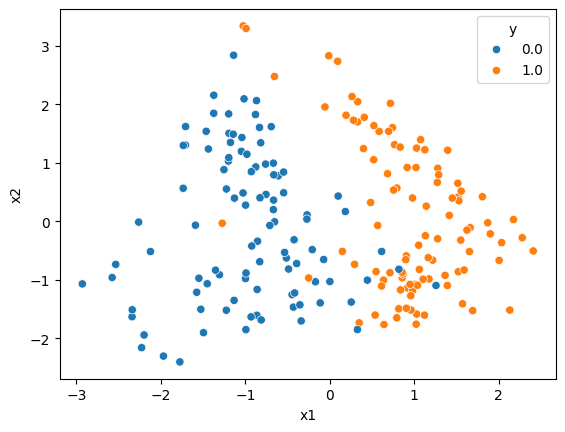

In [429]:
import seaborn as sns
sns.scatterplot(data = df_own, x = 'x1', y = 'x2', hue = 'y')

In [430]:
#knn implementation how ?

idx = np.random.randint(0,df_own.shape[0])
idx

121

In [431]:
test_vector = np.array(df_own.iloc[idx][0:-1])
test_vector

array([1.55664319, 0.51433846])

In [432]:
real_y = np.array(df_own.iloc[idx][-1])
real_y

/tmp/ipykernel_1263/3941960975.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  real_y = np.array(df_own.iloc[idx][-1])


array(1.)

#TEST

In [433]:
l = []
for i in X:
  distance = 0
  for j in range(i.shape[0]):
    distance = distance + (i[j] - test_vector[j])**2
  l.append(np.sqrt(distance))
print(l)

[np.float64(2.2707062319966913), np.float64(4.488425466991473), np.float64(1.9254758239355636), np.float64(2.31924554003813), np.float64(2.558170884755791), np.float64(0.9216228790877139), np.float64(3.199280714867256), np.float64(0.6705276011894818), np.float64(1.3662568779105082), np.float64(2.1823455451083915), np.float64(2.2267932902271306), np.float64(3.4793327333776527), np.float64(2.7653925569406423), np.float64(1.5479095002019396), np.float64(0.3192715940337085), np.float64(1.1494424916968842), np.float64(2.235864636210282), np.float64(2.1623180623641947), np.float64(4.758426438947958), np.float64(2.166979508090298), np.float64(4.278094327935481), np.float64(3.5580813608853528), np.float64(1.3787497102506445), np.float64(2.364439141016325), np.float64(2.5638603724157485), np.float64(2.127982602087175), np.float64(0.9057101855080051), np.float64(4.634625925403372), np.float64(3.1883018981940134), np.float64(3.218363560857709), np.float64(2.467413016765646), np.float64(1.83889149

In [434]:
lol = np.argsort(np.array(l))
lol[1:]
lol[1:].shape

(199,)

In [435]:
y[lol[1:]].shape

(199,)

In [436]:
y[lol[1:]]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0])

In [437]:
y[lol[1:]][:40]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [438]:
l1 = list(y[lol[1:]][:40])

In [439]:
L = []
for i in l1:
    L.append(l1.count(i))
print(L)

[40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40]


In [440]:
d = dict(zip(l1,L))
d

{np.int64(1): 40}

In [441]:
for i in d:
  if d[i] == max(d.values()):
    print(i)

1


#Final

In [442]:
def KNN_Classfier_UKD(query_vector:np.ndarray,df:pd.DataFrame,nearest_neigh = 5):
  y = np.array(df.iloc[:,-1])
  X = np.array(df.iloc[:,0:-1])
  distance_l = []
  neigh_l = []
  for i in X:
    distance = 0
    for j in range(i.shape[0]):
      distance = distance + (i[j] - query_vector[j])**2
    distance_l.append(np.sqrt(distance))
  distance_idx = np.argsort(distance_l)
  for i in list(y[distance_idx][:nearest_neigh]):
    neigh_l.append(list(y[distance_idx][:nearest_neigh]).count(i))
  d = dict(zip(list(y[distance_idx][:nearest_neigh]),neigh_l))
  for i in d:
    if d[i] == max(d.values()):
      return i

In [443]:
KNN_Classfier_UKD(test_vector,df_own,6)

np.float64(1.0)

In [444]:
df.drop(columns = ['Unnamed: 32','id'],inplace = True)

In [445]:
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


In [446]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [447]:
df['diagnosis1'] = df['diagnosis']
df.drop(columns = ['diagnosis'],inplace = True)

In [448]:
df.rename(columns = {'diagnosis1':'diagnosis'},inplace = True)

In [449]:
df

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,1
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,1
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,1
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,1


In [450]:
# df['diagnosis'] = df['diagnosis'].map({
#     'B': 0,
#     'M': 1
# }) more easy

In [451]:
idx = np.random.randint(0,df.shape[0])
print(idx)

226


In [452]:
vector_cancer = np.array(df.iloc[idx])[:-1]
print(vector_cancer)

[1.044e+01 1.546e+01 6.662e+01 3.296e+02 1.053e-01 7.722e-02 6.643e-03
 1.216e-02 1.788e-01 6.450e-02 1.913e-01 9.027e-01 1.208e+00 1.186e+01
 6.513e-03 8.061e-03 2.817e-03 4.972e-03 1.502e-02 2.821e-03 1.152e+01
 1.980e+01 7.347e+01 3.954e+02 1.341e-01 1.153e-01 2.639e-02 4.464e-02
 2.615e-01 8.269e-02]


In [453]:
actual = np.array(df.iloc[idx])[-1]
print(actual)

0.0


In [454]:
df_idx = df.drop(axis = 0,index = idx)

In [455]:
KNN_Classfier_UKD(vector_cancer,df_idx,10)

np.int64(0)